In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.attacks.fgsm import fgsm_attack
from src.attacks.pgd import pgd_attack

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\arvin\Desktop\projects\adversarial-ids


In [2]:
X_val = pd.read_csv(
    PROJECT_ROOT / "data" / "splits" / "X_val.csv"
)

y_val = pd.read_csv(
    PROJECT_ROOT / "data" / "splits" / "y_val.csv"
).squeeze()

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (378120, 70)
y_val shape: (378120,)


In [3]:
X_val_tensor = torch.tensor(
    X_val.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).view(-1, 1)

In [4]:
import torch.nn as nn


class IDSNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [5]:
input_size = X_val.shape[1]

baseline_model = IDSNeuralNetwork(input_size)
baseline_model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models" / "neural_network_baseline.pth",
        map_location="cpu"
    )
)

baseline_model.eval()


adv_model = IDSNeuralNetwork(input_size)
adv_model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models" / "neural_network_adversarial_fgsm.pth",
        map_location="cpu"
    )
)

adv_model.eval()

print("Both models loaded successfully.")

Both models loaded successfully.


In [6]:
loss_fn = nn.BCEWithLogitsLoss()

In [7]:
def calculate_metrics(y_true, y_prob, threshold=0.5):

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).ravel()

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "FPR": fpr,
        "FNR": fnr,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [8]:
def calculate_attack_success_rate(
    y_true,
    clean_pred,
    adv_pred
):
    y_true = np.asarray(y_true).astype(int)
    clean_pred = np.asarray(clean_pred).astype(int)
    adv_pred = np.asarray(adv_pred).astype(int)

    correctly_detected_attacks = (
        (y_true == 1) &
        (clean_pred == 1)
    )

    total_correctly_detected = correctly_detected_attacks.sum()

    if total_correctly_detected == 0:
        return 0.0

    successful_evasions = (
        correctly_detected_attacks &
        (adv_pred == 0)
    ).sum()

    return successful_evasions / total_correctly_detected

In [9]:
with torch.no_grad():

    baseline_logits = baseline_model(
        X_val_tensor
    )

    baseline_prob = torch.sigmoid(
        baseline_logits
    ).numpy().ravel()

baseline_metrics = calculate_metrics(
    y_val.values,
    baseline_prob
)

baseline_pred = (
    baseline_prob >= 0.5
).astype(int)

baseline_metrics

{'Accuracy': 0.9836797841954935,
 'Precision': 0.9600771979073625,
 'Recall': 0.9425627534802148,
 'F1': 0.9512393625006914,
 'ROC-AUC': 0.9987056891375631,
 'PR-AUC': 0.9940012470167873,
 'FPR': np.float64(0.00796476791436363),
 'FNR': np.float64(0.05743724651978516),
 'TN': np.int64(311756),
 'FP': np.int64(2503),
 'FN': np.int64(3668),
 'TP': np.int64(60193)}

In [10]:
with torch.no_grad():

    adv_clean_logits = adv_model(
        X_val_tensor
    )

    adv_clean_prob = torch.sigmoid(
        adv_clean_logits
    ).numpy().ravel()

adv_clean_metrics = calculate_metrics(
    y_val.values,
    adv_clean_prob
)

adv_clean_pred = (
    adv_clean_prob >= 0.5
).astype(int)

adv_clean_metrics

{'Accuracy': 0.9816804189146303,
 'Precision': 0.9715421567003478,
 'Recall': 0.9184322199777643,
 'F1': 0.9442409704502097,
 'ROC-AUC': 0.9984341290555641,
 'PR-AUC': 0.992876134528153,
 'FPR': np.float64(0.005466828316770562),
 'FNR': np.float64(0.08156778002223579),
 'TN': np.int64(312541),
 'FP': np.int64(1718),
 'FN': np.int64(5209),
 'TP': np.int64(58652)}

In [11]:
EPSILONS = [0.001, 0.005, 0.01, 0.05, 0.1]

baseline_results = []

In [12]:
for epsilon in EPSILONS:

    X_adv = fgsm_attack(
        model=baseline_model,
        x=X_val_tensor,
        y=y_val_tensor,
        epsilon=epsilon,
        loss_fn=loss_fn
    )

    with torch.no_grad():

        logits = baseline_model(X_adv)

        prob = torch.sigmoid(
            logits
        ).numpy().ravel()

    metrics = calculate_metrics(
        y_val.values,
        prob
    )

    pred = (
        prob >= 0.5
    ).astype(int)

    asr = calculate_attack_success_rate(
        y_val.values,
        baseline_pred,
        pred
    )

    result = {
        "Model": "Baseline NN",
        "Defense": "None",
        "Attack": "FGSM",
        "Epsilon": epsilon,
        **metrics,
        "Attack Success Rate": asr
    }

    baseline_results.append(result)

    print(
        f"FGSM ε={epsilon}: "
        f"Recall={metrics['Recall']:.4f}, "
        f"F1={metrics['F1']:.4f}, "
        f"ASR={asr:.4f}"
    )

FGSM ε=0.001: Recall=0.9215, F1=0.9098, ASR=0.0223
FGSM ε=0.005: Recall=0.8139, F1=0.7998, ASR=0.1365
FGSM ε=0.01: Recall=0.7091, F1=0.6944, ASR=0.2477
FGSM ε=0.05: Recall=0.4864, F1=0.3806, ASR=0.4839
FGSM ε=0.1: Recall=0.4548, F1=0.2402, ASR=0.5175


In [13]:
for epsilon in EPSILONS:

    alpha = epsilon / 10

    X_adv = pgd_attack(
        model=baseline_model,
        x=X_val_tensor,
        y=y_val_tensor,
        epsilon=epsilon,
        alpha=alpha,
        num_steps=10,
        loss_fn=loss_fn
    )

    with torch.no_grad():

        logits = baseline_model(X_adv)

        prob = torch.sigmoid(
            logits
        ).numpy().ravel()

    metrics = calculate_metrics(
        y_val.values,
        prob
    )

    pred = (
        prob >= 0.5
    ).astype(int)

    asr = calculate_attack_success_rate(
        y_val.values,
        baseline_pred,
        pred
    )

    result = {
        "Model": "Baseline NN",
        "Defense": "None",
        "Attack": "PGD",
        "Epsilon": epsilon,
        **metrics,
        "Attack Success Rate": asr
    }

    baseline_results.append(result)

    print(
        f"PGD ε={epsilon}: "
        f"Recall={metrics['Recall']:.4f}, "
        f"F1={metrics['F1']:.4f}, "
        f"ASR={asr:.4f}"
    )

PGD ε=0.001: Recall=0.9215, F1=0.9098, ASR=0.0223
PGD ε=0.005: Recall=0.8134, F1=0.7993, ASR=0.1370
PGD ε=0.01: Recall=0.7084, F1=0.6919, ASR=0.2485
PGD ε=0.05: Recall=0.4842, F1=0.3728, ASR=0.4863
PGD ε=0.1: Recall=0.4532, F1=0.2223, ASR=0.5191


In [14]:
adv_results = []

In [15]:
for epsilon in EPSILONS:

    X_adv = fgsm_attack(
        model=adv_model,
        x=X_val_tensor,
        y=y_val_tensor,
        epsilon=epsilon,
        loss_fn=loss_fn
    )

    with torch.no_grad():

        logits = adv_model(X_adv)

        prob = torch.sigmoid(
            logits
        ).numpy().ravel()

    metrics = calculate_metrics(
        y_val.values,
        prob
    )

    pred = (
        prob >= 0.5
    ).astype(int)

    asr = calculate_attack_success_rate(
        y_val.values,
        adv_clean_pred,
        pred
    )

    result = {
        "Model": "Adversarially Trained NN",
        "Defense": "FGSM Adversarial Training",
        "Attack": "FGSM",
        "Epsilon": epsilon,
        **metrics,
        "Attack Success Rate": asr
    }

    adv_results.append(result)

    print(
        f"FGSM ε={epsilon}: "
        f"Recall={metrics['Recall']:.4f}, "
        f"F1={metrics['F1']:.4f}, "
        f"ASR={asr:.4f}"
    )

FGSM ε=0.001: Recall=0.9180, F1=0.9429, ASR=0.0004
FGSM ε=0.005: Recall=0.9151, F1=0.9399, ASR=0.0036
FGSM ε=0.01: Recall=0.9098, F1=0.9324, ASR=0.0094
FGSM ε=0.05: Recall=0.7413, F1=0.7873, ASR=0.1928
FGSM ε=0.1: Recall=0.6335, F1=0.6619, ASR=0.3103


In [16]:
for epsilon in EPSILONS:

    alpha = epsilon / 10

    X_adv = pgd_attack(
        model=adv_model,
        x=X_val_tensor,
        y=y_val_tensor,
        epsilon=epsilon,
        alpha=alpha,
        num_steps=10,
        loss_fn=loss_fn
    )

    with torch.no_grad():

        logits = adv_model(X_adv)

        prob = torch.sigmoid(
            logits
        ).numpy().ravel()

    metrics = calculate_metrics(
        y_val.values,
        prob
    )

    pred = (
        prob >= 0.5
    ).astype(int)

    asr = calculate_attack_success_rate(
        y_val.values,
        adv_clean_pred,
        pred
    )

    result = {
        "Model": "Adversarially Trained NN",
        "Defense": "FGSM Adversarial Training",
        "Attack": "PGD",
        "Epsilon": epsilon,
        **metrics,
        "Attack Success Rate": asr
    }

    adv_results.append(result)

    print(
        f"PGD ε={epsilon}: "
        f"Recall={metrics['Recall']:.4f}, "
        f"F1={metrics['F1']:.4f}, "
        f"ASR={asr:.4f}"
    )

PGD ε=0.001: Recall=0.9180, F1=0.9429, ASR=0.0004
PGD ε=0.005: Recall=0.9151, F1=0.9398, ASR=0.0036
PGD ε=0.01: Recall=0.9097, F1=0.9320, ASR=0.0095
PGD ε=0.05: Recall=0.7219, F1=0.7521, ASR=0.2139
PGD ε=0.1: Recall=0.6179, F1=0.5860, ASR=0.3272


In [17]:
robustness_results = pd.DataFrame(
    baseline_results + adv_results
)

robustness_results

,Model,Defense,Attack,Epsilon,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,FNR,TN,FP,FN,TP,Attack Success Rate
0,Baseline NN,None,FGSM,0.001,0.969147,0.898405,0.921533,0.909822,0.996086,0.982203,0.021177,0.078467,307604,6655,5011,58850,0.022312
1,Baseline NN,None,FGSM,0.005,0.931178,0.786166,0.813877,0.799781,0.980925,0.913465,0.044985,0.186123,300122,14137,11886,51975,0.136528
2,Baseline NN,None,FGSM,0.010,0.894608,0.680364,0.709118,0.694443,0.953351,0.829619,0.067699,0.290882,292984,21275,18576,45285,0.247670
3,Baseline NN,None,FGSM,0.050,0.732558,0.312544,0.486447,0.380570,0.615033,0.376842,0.217429,0.513553,245930,68329,32796,31065,0.483910
4,Baseline NN,None,FGSM,0.100,0.514041,0.163192,0.454816,0.240199,0.427701,0.235039,0.473924,0.545184,165324,148935,34816,29045,0.517469
5,Baseline NN,None,PGD,0.001,0.969145,0.898391,0.921533,0.909815,0.996084,0.982197,0.021180,0.078467,307603,6656,5011,58850,0.022312
6,Baseline NN,None,PGD,0.005,0.931022,0.785733,0.813392,0.799323,0.980758,0.912823,0.045074,0.186608,300094,14165,11917,51944,0.137043
7,Baseline NN,None,PGD,0.010,0.893433,0.676113,0.708351,0.691857,0.952523,0.827345,0.068956,0.291649,292589,21670,18625,45236,0.248484
8,Baseline NN,None,PGD,0.050,0.724812,0.303035,0.484161,0.372761,0.589676,0.340630,0.226285,0.515839,243147,71112,32942,30919,0.486336
9,Baseline NN,None,PGD,0.100,0.464353,0.147248,0.453234,0.222281,0.410959,0.205844,0.533388,0.546766,146637,167622,34917,28944,0.519147


In [18]:
results_dir = (
    PROJECT_ROOT /
    "experiments" /
    "results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [19]:
output_file = (
    results_dir /
    "robustness_evaluation.csv"
)

robustness_results.to_csv(
    output_file,
    index=False
)

print("Saved:", output_file)

Saved: c:\Users\arvin\Desktop\projects\adversarial-ids\experiments\results\robustness_evaluation.csv


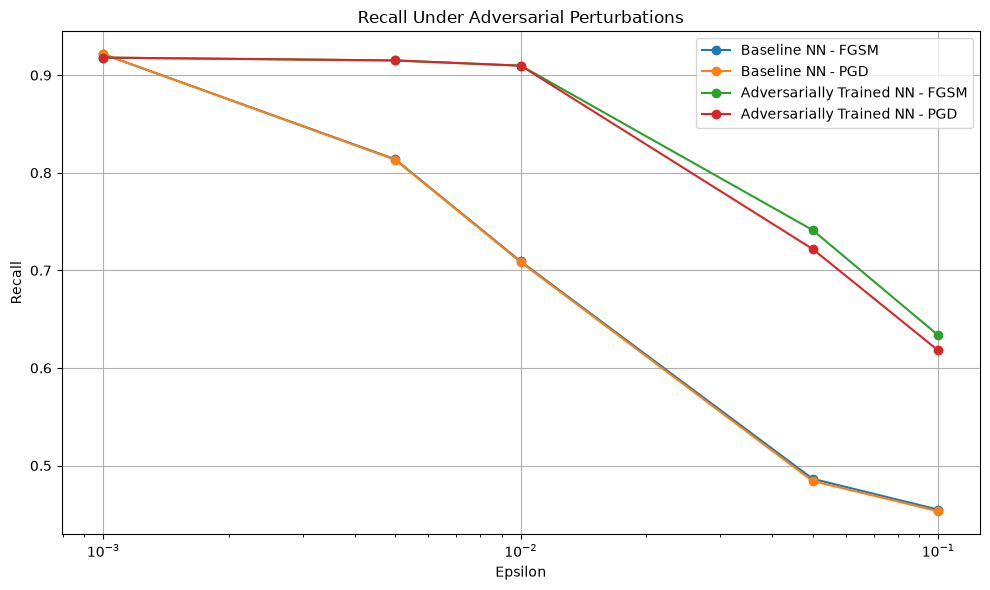

Saved: c:\Users\arvin\Desktop\projects\adversarial-ids\figures\recall_vs_epsilon.png


In [20]:
plt.figure(figsize=(10, 6))

for model_name in robustness_results["Model"].unique():

    for attack_name in ["FGSM", "PGD"]:

        subset = robustness_results[
            (robustness_results["Model"] == model_name) &
            (robustness_results["Attack"] == attack_name)
        ]

        plt.plot(
            subset["Epsilon"],
            subset["Recall"],
            marker="o",
            label=f"{model_name} - {attack_name}"
        )

plt.xlabel("Epsilon")
plt.ylabel("Recall")
plt.title("Recall Under Adversarial Perturbations")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = (
    PROJECT_ROOT /
    "figures" /
    "recall_vs_epsilon.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

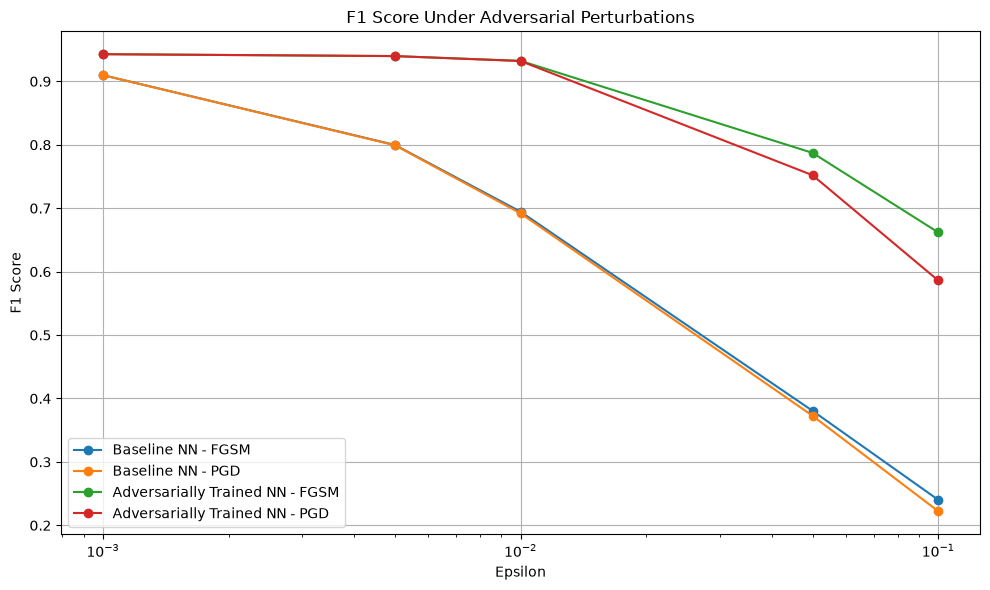

In [21]:
plt.figure(figsize=(10, 6))

for model_name in robustness_results["Model"].unique():

    for attack_name in ["FGSM", "PGD"]:

        subset = robustness_results[
            (robustness_results["Model"] == model_name) &
            (robustness_results["Attack"] == attack_name)
        ]

        plt.plot(
            subset["Epsilon"],
            subset["F1"],
            marker="o",
            label=f"{model_name} - {attack_name}"
        )

plt.xlabel("Epsilon")
plt.ylabel("F1 Score")
plt.title("F1 Score Under Adversarial Perturbations")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = (
    PROJECT_ROOT /
    "figures" /
    "f1_vs_epsilon.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

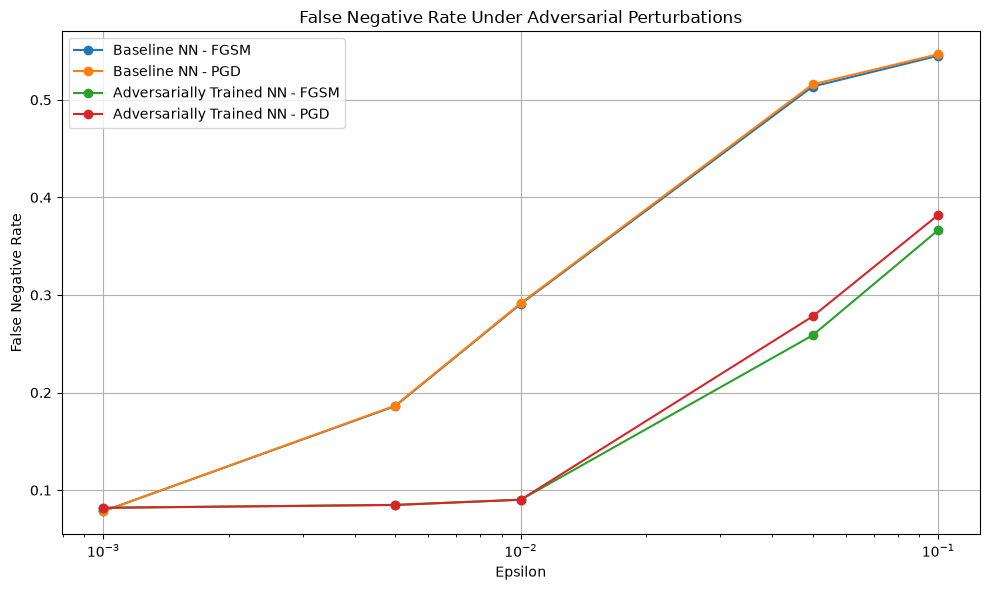

In [22]:
plt.figure(figsize=(10, 6))

for model_name in robustness_results["Model"].unique():

    for attack_name in ["FGSM", "PGD"]:

        subset = robustness_results[
            (robustness_results["Model"] == model_name) &
            (robustness_results["Attack"] == attack_name)
        ]

        plt.plot(
            subset["Epsilon"],
            subset["FNR"],
            marker="o",
            label=f"{model_name} - {attack_name}"
        )

plt.xlabel("Epsilon")
plt.ylabel("False Negative Rate")
plt.title("False Negative Rate Under Adversarial Perturbations")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = (
    PROJECT_ROOT /
    "figures" /
    "fnr_vs_epsilon.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

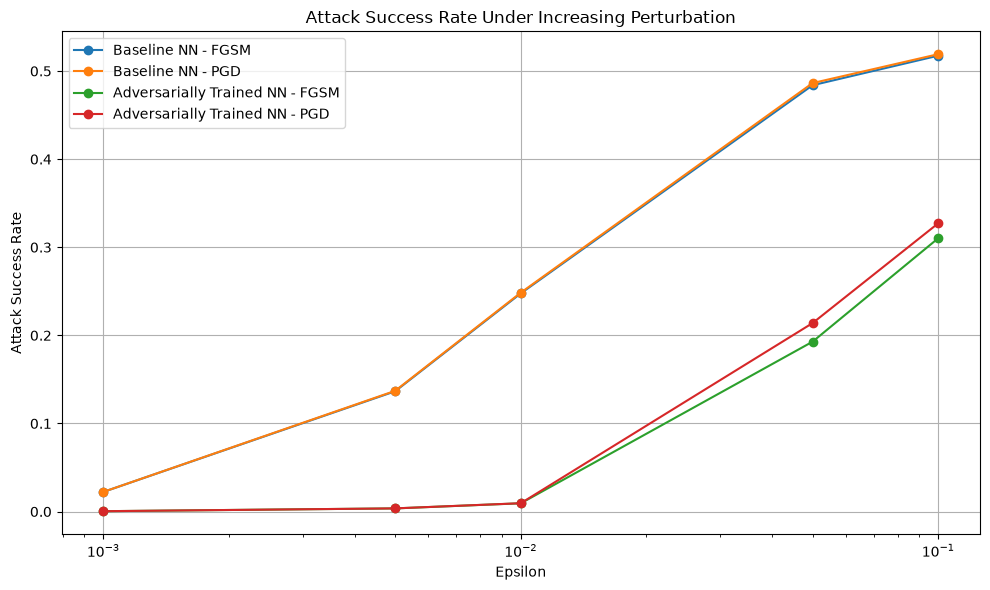

In [23]:
plt.figure(figsize=(10, 6))

for model_name in robustness_results["Model"].unique():

    for attack_name in ["FGSM", "PGD"]:

        subset = robustness_results[
            (robustness_results["Model"] == model_name) &
            (robustness_results["Attack"] == attack_name)
        ]

        plt.plot(
            subset["Epsilon"],
            subset["Attack Success Rate"],
            marker="o",
            label=f"{model_name} - {attack_name}"
        )

plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate")
plt.title("Attack Success Rate Under Increasing Perturbation")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = (
    PROJECT_ROOT /
    "figures" /
    "asr_vs_epsilon.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
comparison = robustness_results[
    [
        "Model",
        "Attack",
        "Epsilon",
        "Accuracy",
        "Recall",
        "F1",
        "FNR",
        "Attack Success Rate"
    ]
].copy()

comparison

,Model,Attack,Epsilon,Accuracy,Recall,F1,FNR,Attack Success Rate
0,Baseline NN,FGSM,0.001,0.969147,0.921533,0.909822,0.078467,0.022312
1,Baseline NN,FGSM,0.005,0.931178,0.813877,0.799781,0.186123,0.136528
2,Baseline NN,FGSM,0.010,0.894608,0.709118,0.694443,0.290882,0.247670
3,Baseline NN,FGSM,0.050,0.732558,0.486447,0.380570,0.513553,0.483910
4,Baseline NN,FGSM,0.100,0.514041,0.454816,0.240199,0.545184,0.517469
5,Baseline NN,PGD,0.001,0.969145,0.921533,0.909815,0.078467,0.022312
6,Baseline NN,PGD,0.005,0.931022,0.813392,0.799323,0.186608,0.137043
7,Baseline NN,PGD,0.010,0.893433,0.708351,0.691857,0.291649,0.248484
8,Baseline NN,PGD,0.050,0.724812,0.484161,0.372761,0.515839,0.486336
9,Baseline NN,PGD,0.100,0.464353,0.453234,0.222281,0.546766,0.519147


In [25]:
comparison.to_csv(
    results_dir / "robustness_comparison.csv",
    index=False
)